# Equities Market Response: Ship Movement + AI Sentiment Analysis

Analyzing how equity markets (US, Europe, Asia) respond to:
- Ship traffic disruptions in Strait of Hormuz
- AI-analyzed geopolitical sentiment
- Regional differences in market response

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
import glob
warnings.filterwarnings('ignore')


plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

plt.rcParams['figure.figsize'] = (20, 12)
plt.rcParams['font.size'] = 11

## 1. Load Data

In [6]:
# Load shipping data
shipping_df = pd.read_csv('Data/Portwatch_Shipment_Data/arrivals-of-ships.csv')
shipping_df['DateTime'] = pd.to_datetime(shipping_df['DateTime'])
shipping_df.set_index('DateTime', inplace=True)
shipping_df['Total'] = shipping_df[['Container', 'Dry Bulk', 'General Cargo', 'Roll-on/roll-off', 'Tanker']].sum(axis=1)
shipping_df['MA_30'] = shipping_df['Total'].rolling(30).mean()
shipping_df['Disruption_Pct'] = ((shipping_df['Total'] - shipping_df['MA_30']) / shipping_df['MA_30']) * 100

# Load sentiment data
sentiment_df = pd.read_csv('Data/crisis_sentiment_analysis.csv')
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])

sentiment_daily = pd.read_csv('Data/crisis_sentiment_daily.csv')
sentiment_daily['date'] = pd.to_datetime(sentiment_daily['date'])
sentiment_daily_indexed = sentiment_daily.set_index('date')

# Load equities data by region
equities = {}

# US Equities
us_files = glob.glob('Data/Equities/US/*.parquet')
print(f'US .parquet files found: {us_files}')
if us_files:
    sample_us = pd.read_parquet(us_files[0])
    print(f'US sample columns: {sample_us.columns.tolist()}')
    print(sample_us.head())
for file in us_files:
    ticker = file.split('/')[-1].replace('.parquet', '')
    df = pd.read_parquet(file)
    df.index = pd.to_datetime(df.index)
    # Handle MultiIndex columns: extract the 'Close' column for this ticker
    if isinstance(df.columns, pd.MultiIndex):
        if ('Close', ticker) in df.columns:
            close_series = df[('Close', ticker)]
        else:
            print(f'WARNING: (Close, {ticker}) not found in {file}')
            continue
    else:
        if 'Close' in df.columns:
            close_series = df['Close']
        else:
            print(f'WARNING: Close column not found in {file}')
            continue
    close_series.name = f'US_{ticker}'
    equities[f'US_{ticker}'] = close_series

# Europe Equities
europe_files = glob.glob('Data/Equities/Europe/*.parquet')
print(f'Europe .parquet files found: {europe_files}')
if europe_files:
    sample_eu = pd.read_parquet(europe_files[0])
    print(f'Europe sample columns: {sample_eu.columns.tolist()}')
    print(sample_eu.head())
for file in europe_files:
    ticker = file.split('/')[-1].replace('.parquet', '')
    df = pd.read_parquet(file)
    df.index = pd.to_datetime(df.index)
    if isinstance(df.columns, pd.MultiIndex):
        if ('Close', ticker) in df.columns:
            close_series = df[('Close', ticker)]
        else:
            print(f'WARNING: (Close, {ticker}) not found in {file}')
            continue
    else:
        if 'Close' in df.columns:
            close_series = df['Close']
        else:
            print(f'WARNING: Close column not found in {file}')
            continue
    close_series.name = f'EU_{ticker}'
    equities[f'EU_{ticker}'] = close_series

# Asia Equities
asia_files = glob.glob('Data/Equities/Asia/*.parquet')
print(f'Asia .parquet files found: {asia_files}')
if asia_files:
    sample_asia = pd.read_parquet(asia_files[0])
    print(f'Asia sample columns: {sample_asia.columns.tolist()}')
    print(sample_asia.head())
for file in asia_files:
    ticker = file.split('/')[-1].replace('.parquet', '')
    df = pd.read_parquet(file)
    df.index = pd.to_datetime(df.index)
    if isinstance(df.columns, pd.MultiIndex):
        if ('Close', ticker) in df.columns:
            close_series = df[('Close', ticker)]
        else:
            print(f'WARNING: (Close, {ticker}) not found in {file}')
            continue
    else:
        if 'Close' in df.columns:
            close_series = df['Close']
        else:
            print(f'WARNING: Close column not found in {file}')
            continue
    close_series.name = f'ASIA_{ticker}'
    equities[f'ASIA_{ticker}'] = close_series

if not equities:
    print("WARNING: No equity .parquet files found in US, Europe, or Asia folders. DataFrame will be empty.")
    equities_df = pd.DataFrame()
else:
    equities_df = pd.DataFrame(equities)

print(f"Loaded {len(equities_df.columns)} equity tickers")
print(f"  US: {len([c for c in equities_df.columns if c.startswith('US_')])}")
print(f"  Europe: {len([c for c in equities_df.columns if c.startswith('EU_')])}")
print(f"  Asia: {len([c for c in equities_df.columns if c.startswith('ASIA_')])}")
if not equities_df.empty:
    print(f"Date range: {equities_df.index.min()} to {equities_df.index.max()}")
else:
    print("Equities DataFrame is empty.")

US .parquet files found: ['Data/Equities/US/EOG.parquet', 'Data/Equities/US/COP.parquet', 'Data/Equities/US/HAL.parquet', 'Data/Equities/US/BA.parquet', 'Data/Equities/US/STNG.parquet', 'Data/Equities/US/ITA.parquet', 'Data/Equities/US/XLE.parquet', 'Data/Equities/US/DHT.parquet', 'Data/Equities/US/JETS.parquet', 'Data/Equities/US/FRO.parquet', 'Data/Equities/US/XLI.parquet', 'Data/Equities/US/LMT.parquet', 'Data/Equities/US/SLB.parquet', 'Data/Equities/US/TNK.parquet', 'Data/Equities/US/CVX.parquet', 'Data/Equities/US/SPY.parquet', 'Data/Equities/US/WDS.parquet', 'Data/Equities/US/LNG.parquet', 'Data/Equities/US/XOM.parquet']
US sample columns: [('Close', 'EOG')]
Price           Close
Ticker            EOG
Date                 
2018-12-31  65.084030
2019-01-02  67.621437
2019-01-03  67.143822
2019-01-04  70.091675
2019-01-07  70.531975
Europe .parquet files found: ['Data/Equities/Europe/EZU.parquet', 'Data/Equities/Europe/NORW.parquet', 'Data/Equities/Europe/EPOL.parquet', 'Data/Equit

## 2. Merge and Prepare Analysis Data

In [3]:
# Merge all data
analysis_df = equities_df.copy()
analysis_df = analysis_df.join(shipping_df[['Total', 'Disruption_Pct']], how='left')
analysis_df = analysis_df.join(sentiment_daily_indexed[['sentiment_mean', 'article_count']], how='left')

# Forward fill shipping data
analysis_df['Disruption_Pct'] = analysis_df['Disruption_Pct'].fillna(method='ffill')
analysis_df['sentiment_mean'] = analysis_df['sentiment_mean'].fillna(0)

# Calculate returns
for col in equities_df.columns:
    analysis_df[f'{col}_Return'] = analysis_df[col].pct_change()

# Create regional indices
us_cols = [c for c in equities_df.columns if c.startswith('US_')]
eu_cols = [c for c in equities_df.columns if c.startswith('EU_')]
asia_cols = [c for c in equities_df.columns if c.startswith('ASIA_')]

analysis_df['US_Index'] = analysis_df[[f'{c}_Return' for c in us_cols]].mean(axis=1)
analysis_df['EU_Index'] = analysis_df[[f'{c}_Return' for c in eu_cols]].mean(axis=1)
analysis_df['ASIA_Index'] = analysis_df[[f'{c}_Return' for c in asia_cols]].mean(axis=1)

# Crisis indicators
analysis_df['Shipping_Crisis'] = (analysis_df['Disruption_Pct'] < -20).astype(int)
analysis_df['Sentiment_Crisis'] = (analysis_df['sentiment_mean'] < -0.5).astype(int)
analysis_df['Combined_Crisis'] = ((analysis_df['Shipping_Crisis'] == 1) | 
                                   (analysis_df['Sentiment_Crisis'] == 1)).astype(int)

print(f"\nAnalysis DataFrame: {analysis_df.shape}")
print(f"Crisis days: {analysis_df['Combined_Crisis'].sum()}")


Analysis DataFrame: (1802, 84)
Crisis days: 133


## 3. Regional Index Performance

In [9]:
# Event study analysis: Returns around crisis events
def event_study(df, crisis_col, index_cols, window=7):
    """
    Analyze returns in windows around crisis events
    
    Parameters:
    - df: DataFrame with crisis flags and returns
    - crisis_col: Column name for crisis indicator
    - index_cols: List of regional index columns
    - window: Days before/after to analyze
    """
    # Find crisis dates
    crisis_dates = df[df[crisis_col] == 1].index
    
    if len(crisis_dates) == 0:
        print(f"No {crisis_col} events found")
        return None
    
    print(f"\n{crisis_col}: {len(crisis_dates)} events")
    
    # Collect returns for each event window
    event_windows = []
    
    for crisis_date in crisis_dates:
        # Get window around crisis
        start_idx = max(0, df.index.get_loc(crisis_date) - window)
        end_idx = min(len(df), df.index.get_loc(crisis_date) + window + 1)
        
        window_data = df.iloc[start_idx:end_idx][index_cols].copy()
        window_data['days_from_event'] = range(-len(window_data[:df.index.get_loc(crisis_date) - start_idx]), 
                                                len(window_data) - len(window_data[:df.index.get_loc(crisis_date) - start_idx]))
        window_data['event_date'] = crisis_date
        
        event_windows.append(window_data)
    
    # Combine all event windows
    all_events = pd.concat(event_windows)
    
    # Calculate average returns by days from event
    avg_returns = all_events.groupby('days_from_event')[index_cols].mean()
    
    # Calculate cumulative returns
    cum_returns = (1 + avg_returns).cumprod() - 1
    cum_returns = cum_returns * 100  # Convert to percentage
    
    return {
        'avg_returns': avg_returns * 100,  # Convert to percentage
        'cum_returns': cum_returns,
        'event_count': len(crisis_dates),
        'all_events': all_events
    }


# Load the analysis data (assuming it's already prepared)
print("Loading data...")
# You would load your analysis_df here
# For now, this is a template

def compare_crisis_types(analysis_df, window=7):
    """
    Compare different crisis types using event study methodology
    """
    
    # Define crisis types
    crisis_types = {
        'Shipping Crisis': 'Shipping_Crisis',
        'Sentiment Crisis': 'Sentiment_Crisis',
        'Combined Crisis': None  # Will calculate as both
    }
    
    index_cols = ['US_Index', 'EU_Index', 'ASIA_Index']
    
    results = {}
    
    # Analyze each crisis type
    for crisis_name, crisis_col in crisis_types.items():
        if crisis_col is None:
            # Combined crisis: both flags = 1
            temp_df = analysis_df.copy()
            temp_df['temp_combined'] = ((temp_df['Shipping_Crisis'] == 1) & 
                                        (temp_df['Sentiment_Crisis'] == 1)).astype(int)
            result = event_study(temp_df, 'temp_combined', index_cols, window)
        else:
            result = event_study(analysis_df, crisis_col, index_cols, window)
        
        if result is not None:
            results[crisis_name] = result
    
    # Also analyze "Normal" periods for comparison
    temp_df = analysis_df.copy()
    # Sample random normal days
    normal_dates = temp_df[(temp_df['Shipping_Crisis'] == 0) & 
                           (temp_df['Sentiment_Crisis'] == 0)].sample(min(20, len(temp_df))).index
    temp_df['temp_normal'] = 0
    temp_df.loc[normal_dates, 'temp_normal'] = 1
    normal_result = event_study(temp_df, 'temp_normal', index_cols, window)
    if normal_result is not None:
        results['Normal (Sample)'] = normal_result
    
    return results


def plot_event_study(results, window=7):
    """
    Visualize event study results
    """
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    
    regions = ['US_Index', 'EU_Index', 'ASIA_Index']
    region_names = ['US', 'Europe', 'Asia']
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    
    # Plot 1: Cumulative returns - Shipping Crisis
    ax = axes[0, 0]
    if 'Shipping Crisis' in results:
        for region, name, color in zip(regions, region_names, colors):
            ax.plot(results['Shipping Crisis']['cum_returns'].index, 
                   results['Shipping Crisis']['cum_returns'][region],
                   label=name, linewidth=2, color=color, marker='o')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Crisis Day')
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.set_title('Shipping Crisis: Cumulative Returns Around Event', fontsize=14, fontweight='bold')
    ax.set_xlabel('Days from Crisis Event')
    ax.set_ylabel('Cumulative Return (%)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 2: Cumulative returns - Sentiment Crisis
    ax = axes[0, 1]
    if 'Sentiment Crisis' in results:
        for region, name, color in zip(regions, region_names, colors):
            ax.plot(results['Sentiment Crisis']['cum_returns'].index, 
                   results['Sentiment Crisis']['cum_returns'][region],
                   label=name, linewidth=2, color=color, marker='o')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Crisis Day')
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.set_title('Sentiment Crisis: Cumulative Returns Around Event', fontsize=14, fontweight='bold')
    ax.set_xlabel('Days from Crisis Event')
    ax.set_ylabel('Cumulative Return (%)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 3: Cumulative returns - Combined Crisis
    ax = axes[1, 0]
    if 'Combined Crisis' in results:
        for region, name, color in zip(regions, region_names, colors):
            ax.plot(results['Combined Crisis']['cum_returns'].index, 
                   results['Combined Crisis']['cum_returns'][region],
                   label=name, linewidth=2, color=color, marker='o')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Crisis Day')
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.set_title('Combined Crisis: Cumulative Returns Around Event', fontsize=14, fontweight='bold')
    ax.set_xlabel('Days from Crisis Event')
    ax.set_ylabel('Cumulative Return (%)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 4: Comparison of all crisis types (US only for clarity)
    ax = axes[1, 1]
    for crisis_type, result in results.items():
        ax.plot(result['cum_returns'].index, 
               result['cum_returns']['US_Index'],
               label=f"{crisis_type} (n={result['event_count']})", 
               linewidth=2, marker='o')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Crisis Day')
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.set_title('US Market: Comparison Across Crisis Types', fontsize=14, fontweight='bold')
    ax.set_xlabel('Days from Crisis Event')
    ax.set_ylabel('Cumulative Return (%)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig


def print_summary_stats(results):
    """
    Print summary statistics for each crisis type
    """
    print("\n" + "="*80)
    print("EVENT STUDY SUMMARY STATISTICS")
    print("="*80)
    
    for crisis_type, result in results.items():
        print(f"\n{crisis_type} ({result['event_count']} events):")
        print("-" * 60)
        
        # Pre-crisis (days -7 to -1)
        pre_crisis = result['avg_returns'].loc[-7:-1]
        print(f"\nPre-Crisis Period (Days -7 to -1):")
        print(f"  US:     {pre_crisis['US_Index'].mean():>7.2f}% avg daily return")
        print(f"  Europe: {pre_crisis['EU_Index'].mean():>7.2f}% avg daily return")
        print(f"  Asia:   {pre_crisis['ASIA_Index'].mean():>7.2f}% avg daily return")
        
        # Crisis day
        crisis_day = result['avg_returns'].loc[0]
        print(f"\nCrisis Day (Day 0):")
        print(f"  US:     {crisis_day['US_Index']:>7.2f}%")
        print(f"  Europe: {crisis_day['EU_Index']:>7.2f}%")
        print(f"  Asia:   {crisis_day['ASIA_Index']:>7.2f}%")
        
        # Post-crisis (days +1 to +7)
        post_crisis = result['avg_returns'].loc[1:7]
        print(f"\nPost-Crisis Period (Days +1 to +7):")
        print(f"  US:     {post_crisis['US_Index'].mean():>7.2f}% avg daily return")
        print(f"  Europe: {post_crisis['EU_Index'].mean():>7.2f}% avg daily return")
        print(f"  Asia:   {post_crisis['ASIA_Index'].mean():>7.2f}% avg daily return")
        
        # Total cumulative impact
        total_impact = result['cum_returns'].iloc[-1]
        print(f"\nTotal Cumulative Return (Day -7 to +7):")
        print(f"  US:     {total_impact['US_Index']:>7.2f}%")
        print(f"  Europe: {total_impact['EU_Index']:>7.2f}%")
        print(f"  Asia:   {total_impact['ASIA_Index']:>7.2f}%")


results = compare_crisis_types(analysis_df, window=7)
print_summary_stats(results)


Loading data...

Shipping_Crisis: 115 events

Sentiment_Crisis: 19 events

temp_combined: 1 events

temp_normal: 20 events

EVENT STUDY SUMMARY STATISTICS

Shipping Crisis (115 events):
------------------------------------------------------------

Pre-Crisis Period (Days -7 to -1):
  US:       -0.01% avg daily return
  Europe:    0.01% avg daily return
  Asia:      0.06% avg daily return

Crisis Day (Day 0):
  US:       -0.23%
  Europe:   -0.20%
  Asia:     -0.05%

Post-Crisis Period (Days +1 to +7):
  US:        0.05% avg daily return
  Europe:    0.09% avg daily return
  Asia:      0.10% avg daily return

Total Cumulative Return (Day -7 to +7):
  US:        0.04%
  Europe:    0.44%
  Asia:      1.07%

Sentiment Crisis (19 events):
------------------------------------------------------------

Pre-Crisis Period (Days -7 to -1):
  US:        0.21% avg daily return
  Europe:    0.10% avg daily return
  Asia:      0.12% avg daily return

Crisis Day (Day 0):
  US:        0.16%
  Europe:   

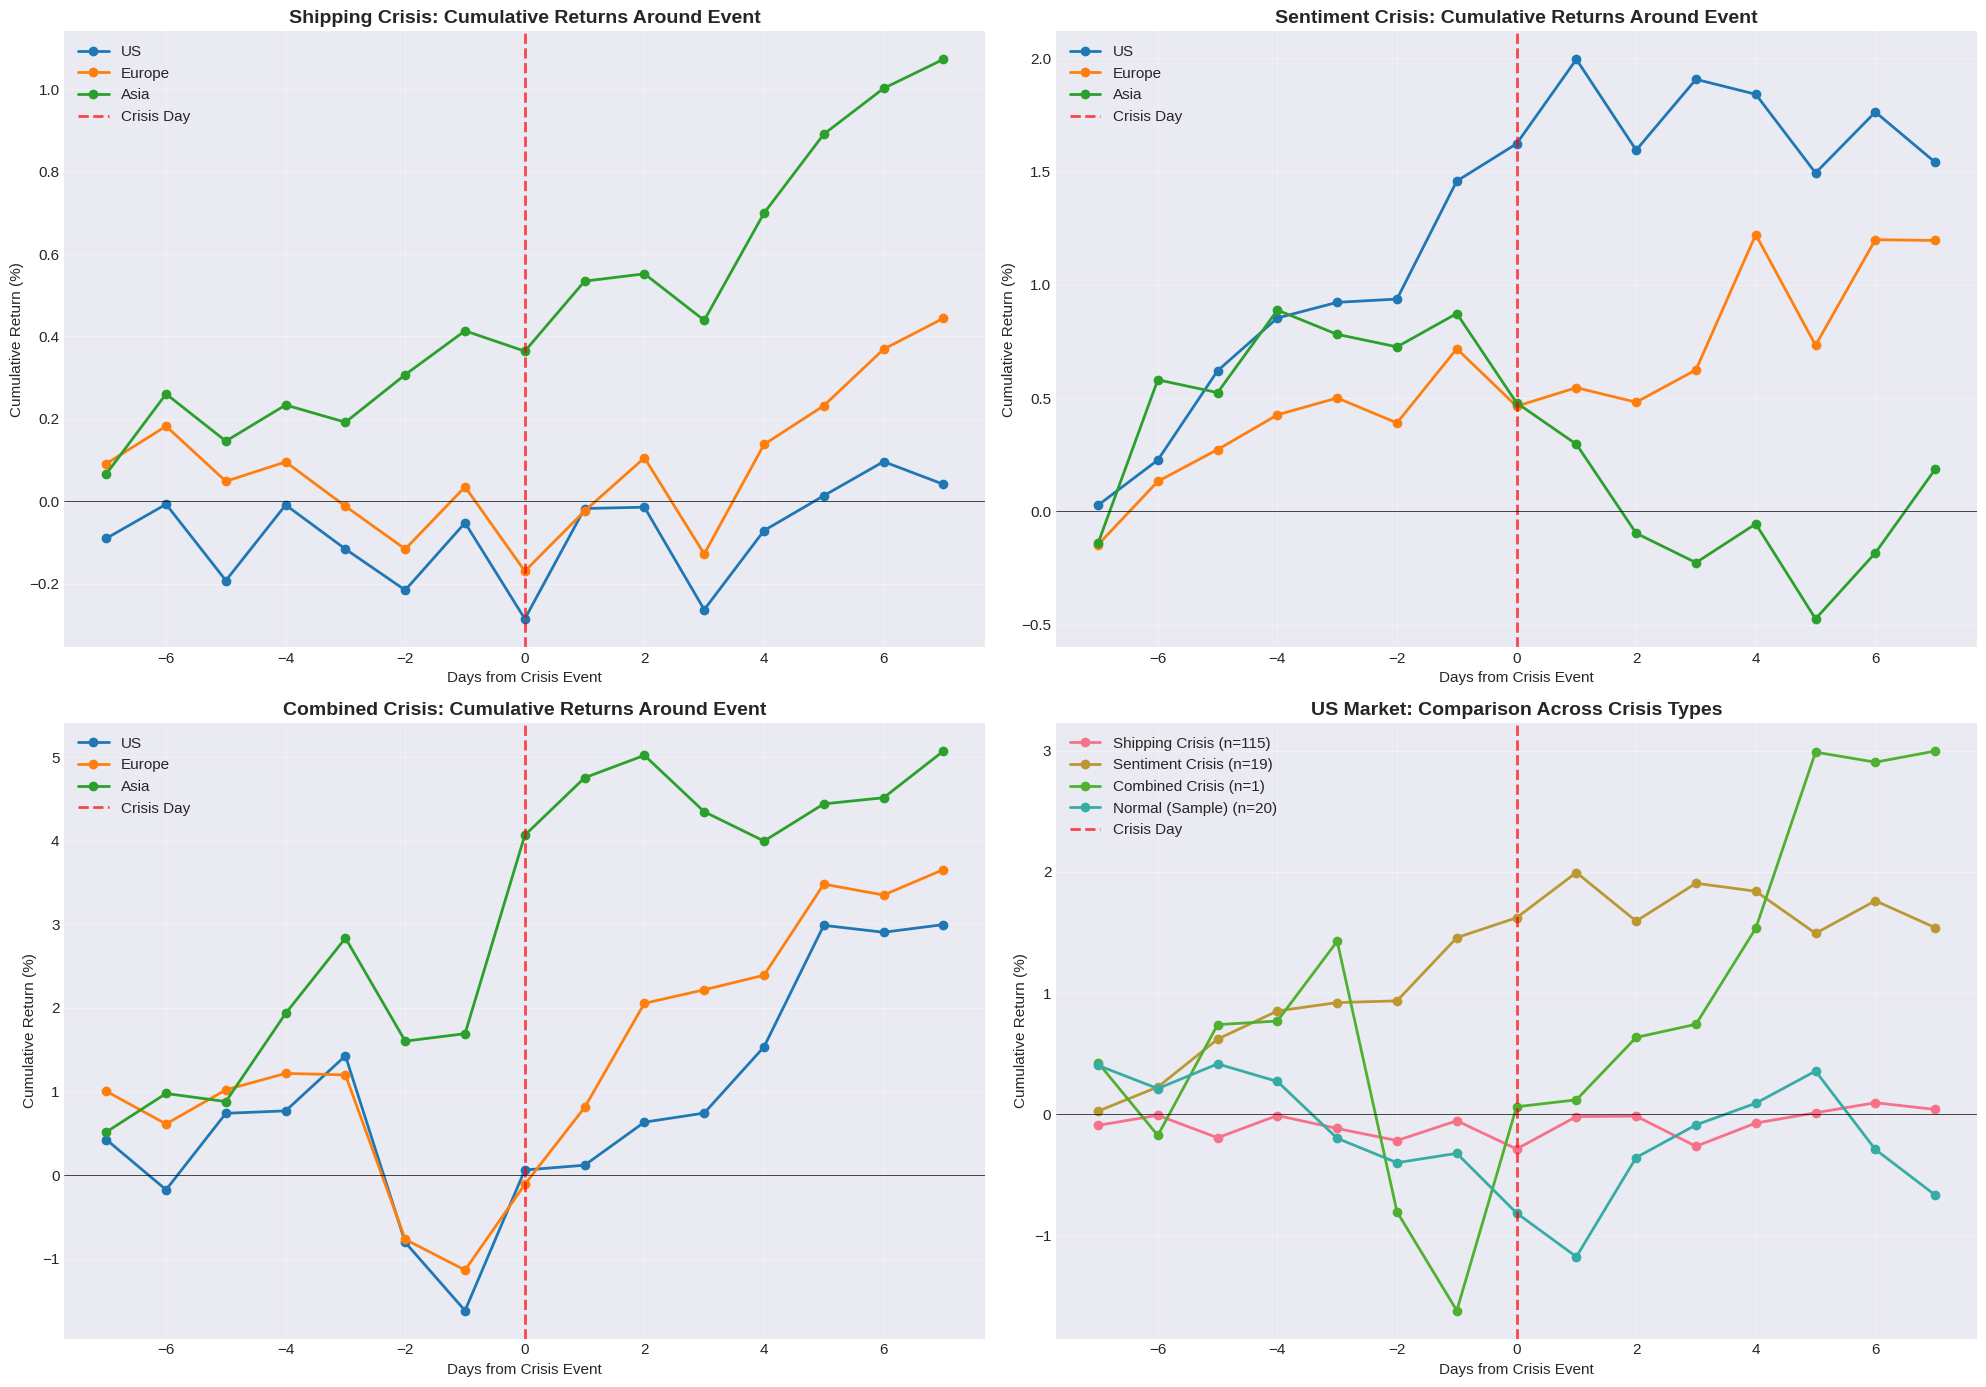

In [8]:
# Plot results
fig = plot_event_study(results, window=7)
plt.show()

In [ ]:
# Visualize regional performance
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# Plot 1: Returns by region and scenario
return_cols = ['US', 'Europe', 'Asia']
regional_df[return_cols].plot(kind='bar', ax=axes[0, 0], width=0.8)
axes[0, 0].set_title('Regional Equity Returns by Scenario', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Annualized Return (%)')
axes[0, 0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[0, 0].legend(title='Region')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=45, ha='right')

# Plot 2: Volatility by region and scenario
vol_cols = ['US_Vol', 'EU_Vol', 'Asia_Vol']
regional_df[vol_cols].plot(kind='bar', ax=axes[0, 1], width=0.8)
axes[0, 1].set_title('Regional Equity Volatility by Scenario', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Annualized Volatility (%)')
axes[0, 1].legend(title='Region', labels=['US', 'Europe', 'Asia'])
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=45, ha='right')

# Plot 3: Impact (difference from normal)
impact_df = regional_df[return_cols].subtract(regional_df.loc['Normal'][return_cols], axis=1)
impact_df.drop('Normal').plot(kind='bar', ax=axes[1, 0], width=0.8)
axes[1, 0].set_title('Crisis Impact on Regional Returns (vs Normal)', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Return Difference (%)')
axes[1, 0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1, 0].legend(title='Region')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=45, ha='right')

# Plot 4: Sharpe ratios
sharpe_df = pd.DataFrame()
for region in ['US', 'Europe', 'Asia']:
    vol_col = f'{region.split()[0] if " " not in region else region}_Vol' if region != 'Europe' else 'EU_Vol'
    sharpe_df[region] = regional_df[region] / regional_df[vol_col]

sharpe_df.plot(kind='bar', ax=axes[1, 1], width=0.8)
axes[1, 1].set_title('Regional Sharpe Ratios by Scenario', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Sharpe Ratio')
axes[1, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1, 1].legend(title='Region')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

## 4. Sector Analysis (Energy, Defense, Transportation)

In [ ]:
# Define sector groupings
sectors = {
    'Energy': ['US_XLE', 'US_XOM', 'US_CVX', 'US_COP', 'US_EOG', 'US_HAL', 'US_SLB', 'EU_IEO', 'EU_EQNR'],
    'Defense/Aerospace': ['US_LMT', 'US_BA', 'US_ITA'],
    'Transportation': ['US_JETS', 'US_BDRY'],
    'Shipping/Tankers': ['US_DHT', 'US_FRO', 'US_STNG', 'US_TNK'],
    'LNG': ['US_LNG', 'US_WDS'],
    'Broad Market': ['US_SPY', 'US_XLI', 'EU_EZU', 'ASIA_FXI', 'ASIA_EWJ']
}

sector_results = {}
for sector_name, tickers in sectors.items():
    # Filter tickers that exist in our data
    available_tickers = [t for t in tickers if t in equities_df.columns]
    if not available_tickers:
        continue
    
    return_cols = [f'{t}_Return' for t in available_tickers]
    sector_return = analysis_df[return_cols].mean(axis=1)
    
    sector_results[sector_name] = {}
    for scenario_name, mask in scenarios.items():
        scenario_data = sector_return[mask]
        sector_results[sector_name][scenario_name] = scenario_data.mean() * 252 * 100

sector_df = pd.DataFrame(sector_results).T
print("\nSector Performance by Scenario (Annualized %):")
print(sector_df.round(2))

In [ ]:
# Visualize sector performance
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Plot 1: Sector returns by scenario
sector_df.T.plot(kind='bar', ax=axes[0], width=0.8)
axes[0].set_title('Sector Performance by Scenario', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Annualized Return (%)')
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[0].legend(title='Sector', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# Plot 2: Crisis impact by sector
sector_impact = sector_df.subtract(sector_df['Normal'], axis=0).drop('Normal', axis=1)
sector_impact.T.plot(kind='bar', ax=axes[1], width=0.8)
axes[1].set_title('Sector Crisis Impact (vs Normal)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Return Difference (%)')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].legend(title='Sector', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

## 5. Individual Stock Winners and Losers

In [ ]:
# Calculate performance for all stocks during combined crisis
combined_crisis_mask = (analysis_df['Shipping_Crisis'] == 1) & (analysis_df['Sentiment_Crisis'] == 1)
normal_mask = analysis_df['Combined_Crisis'] == 0

stock_performance = {}
for col in equities_df.columns:
    return_col = f'{col}_Return'
    crisis_ret = analysis_df[combined_crisis_mask][return_col].mean() * 252 * 100
    normal_ret = analysis_df[normal_mask][return_col].mean() * 252 * 100
    stock_performance[col] = {
        'Normal': normal_ret,
        'Crisis': crisis_ret,
        'Impact': crisis_ret - normal_ret
    }

stock_perf_df = pd.DataFrame(stock_performance).T

print("\nTOP 10 WINNERS During Combined Crisis:")
print(stock_perf_df.nlargest(10, 'Crisis')[['Normal', 'Crisis', 'Impact']].round(2))

print("\nTOP 10 LOSERS During Combined Crisis:")
print(stock_perf_df.nsmallest(10, 'Crisis')[['Normal', 'Crisis', 'Impact']].round(2))

## 6. Correlation Analysis

In [ ]:
# Calculate correlations with disruption and sentiment
corr_data = {
    'Shipping_Disruption': [],
    'Sentiment': [],
    'Ticker': []
}

for col in equities_df.columns:
    return_col = f'{col}_Return'
    ship_corr = analysis_df[[return_col, 'Disruption_Pct']].corr().iloc[0, 1]
    sent_corr = analysis_df[[return_col, 'sentiment_mean']].corr().iloc[0, 1]
    
    corr_data['Ticker'].append(col)
    corr_data['Shipping_Disruption'].append(ship_corr)
    corr_data['Sentiment'].append(sent_corr)

corr_df = pd.DataFrame(corr_data).set_index('Ticker')

print("\nMost NEGATIVELY correlated with Shipping Disruption (hurt by crisis):")
print(corr_df.nsmallest(10, 'Shipping_Disruption')['Shipping_Disruption'].round(3))

print("\nMost POSITIVELY correlated with Shipping Disruption (benefit from crisis):")
print(corr_df.nlargest(10, 'Shipping_Disruption')['Shipping_Disruption'].round(3))

## 7. Key Insights

In [ ]:
print("\n" + "="*80)
print("KEY INSIGHTS - EQUITIES RESPONSE TO SHIPPING + SENTIMENT")
print("="*80)

print("\n1. REGIONAL IMPACT RANKING:")
combined_crisis_regional = regional_df.loc['Combined Crisis'][return_cols].sort_values()
for region, ret in combined_crisis_regional.items():
    impact = ret - regional_df.loc['Normal'][region]
    print(f"   {region}: {ret:+.2f}% (Impact: {impact:+.2f}%)")

print("\n2. BEST PERFORMING SECTORS During Combined Crisis:")
best_sectors = sector_df['Combined Crisis'].sort_values(ascending=False).head(3)
for sector, ret in best_sectors.items():
    print(f"   {sector}: {ret:+.2f}%")

print("\n3. WORST PERFORMING SECTORS During Combined Crisis:")
worst_sectors = sector_df['Combined Crisis'].sort_values().head(3)
for sector, ret in worst_sectors.items():
    print(f"   {sector}: {ret:+.2f}%")

print("\n4. VOLATILITY CHANGES:")
for region in ['US', 'Europe', 'Asia']:
    vol_col = 'US_Vol' if region == 'US' else ('EU_Vol' if region == 'Europe' else 'ASIA_Vol')
    normal_vol = regional_df.loc['Normal'][vol_col]
    crisis_vol = regional_df.loc['Combined Crisis'][vol_col]
    vol_change = ((crisis_vol / normal_vol) - 1) * 100
    print(f"   {region}: {normal_vol:.1f}% → {crisis_vol:.1f}% (+{vol_change:.1f}%)")

print("\n5. TRADING STRATEGY:")
print("   During Shipping + Sentiment Crisis:")
top_winners = stock_perf_df.nlargest(3, 'Impact')
print(f"   - LONG: {', '.join(top_winners.index.tolist())}")
top_losers = stock_perf_df.nsmallest(3, 'Impact')
print(f"   - SHORT: {', '.join(top_losers.index.tolist())}")

print("\n" + "="*80)